In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from simulation.rules import *
from simulation.simulate import *
from config import *
import random

In [2]:
drive_list = pd.read_csv(DATA_DIR/DRIVE_FILE)
ko_list = pd.read_csv(DATA_DIR/KO_FILE)

In [3]:
yards = random.randint(1,99)
time = random.randint(1, 600)
score_diff = random.randint(-7,7)
print(f'Drive starting at the {yards} yardline. {time} s remaining. Score diff is {score_diff}.')

Drive starting at the 30 yardline. 354 s remaining. Score diff is 0.


In [4]:
int(ko_list[ko_list['season'] == 2025]['starting_field_position'].mean())

68

In [5]:
drive_list[drive_list['start_yardline'] == 69]['drive_result'].value_counts(normalize = True)

drive_result
PUNT                   0.418979
TOUCHDOWN              0.203152
FIELD_GOAL             0.130182
INTERCEPTION           0.081535
DOWNS                  0.046591
FUMBLE                 0.044193
END_HALF               0.025694
MISSED_FG              0.024323
END_GAME               0.021583
BLOCKED_PUNT           0.001713
BLOCKED_FG             0.001370
BLOCKED_PUNT,_DOWNS    0.000685
Name: proportion, dtype: float64

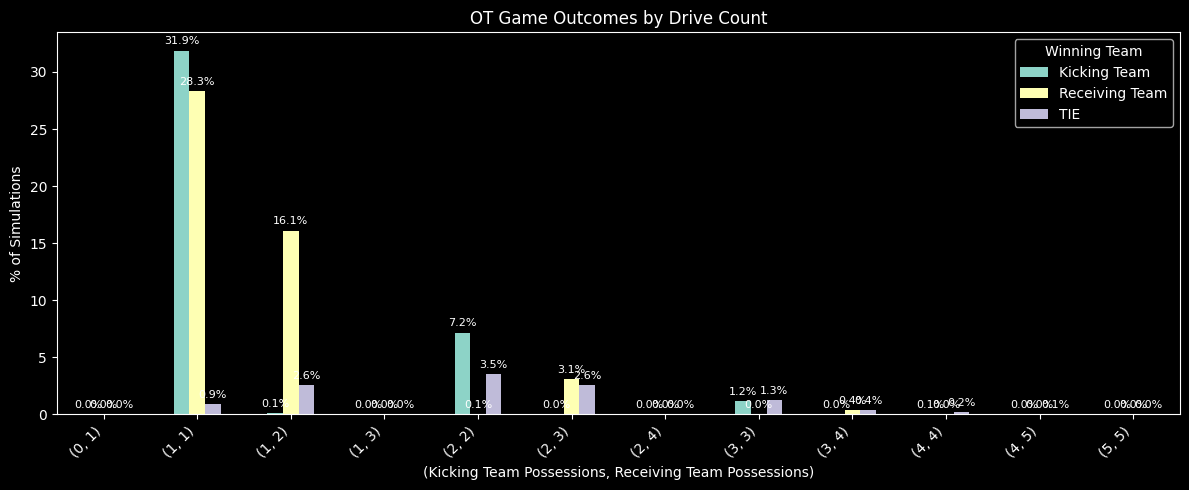

In [7]:
df2025 = pd.read_csv(output_file(2025, n=SIM_NUM, goforit_2pc= False, goforit_fg = True))

counts = (
    df2025.groupby(['Kicking Team Possessions', 'Receiving Team Possessions', 'Winning Team'])['Winning Team']
    .count()
    .unstack('Winning Team', fill_value=0)
)
pcts = counts / len(df2025) * 100

ax = pcts.plot(kind='bar', figsize=(12, 5))
ax.set_xlabel('(Kicking Team Possessions, Receiving Team Possessions)')
ax.set_ylabel('% of Simulations')
ax.set_title('OT Game Outcomes by Drive Count')
ax.legend(title='Winning Team')
plt.xticks(rotation=45, ha='right')

# Add data labels to each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='edge', padding=3, fontsize=8)

plt.tight_layout()
plt.show()

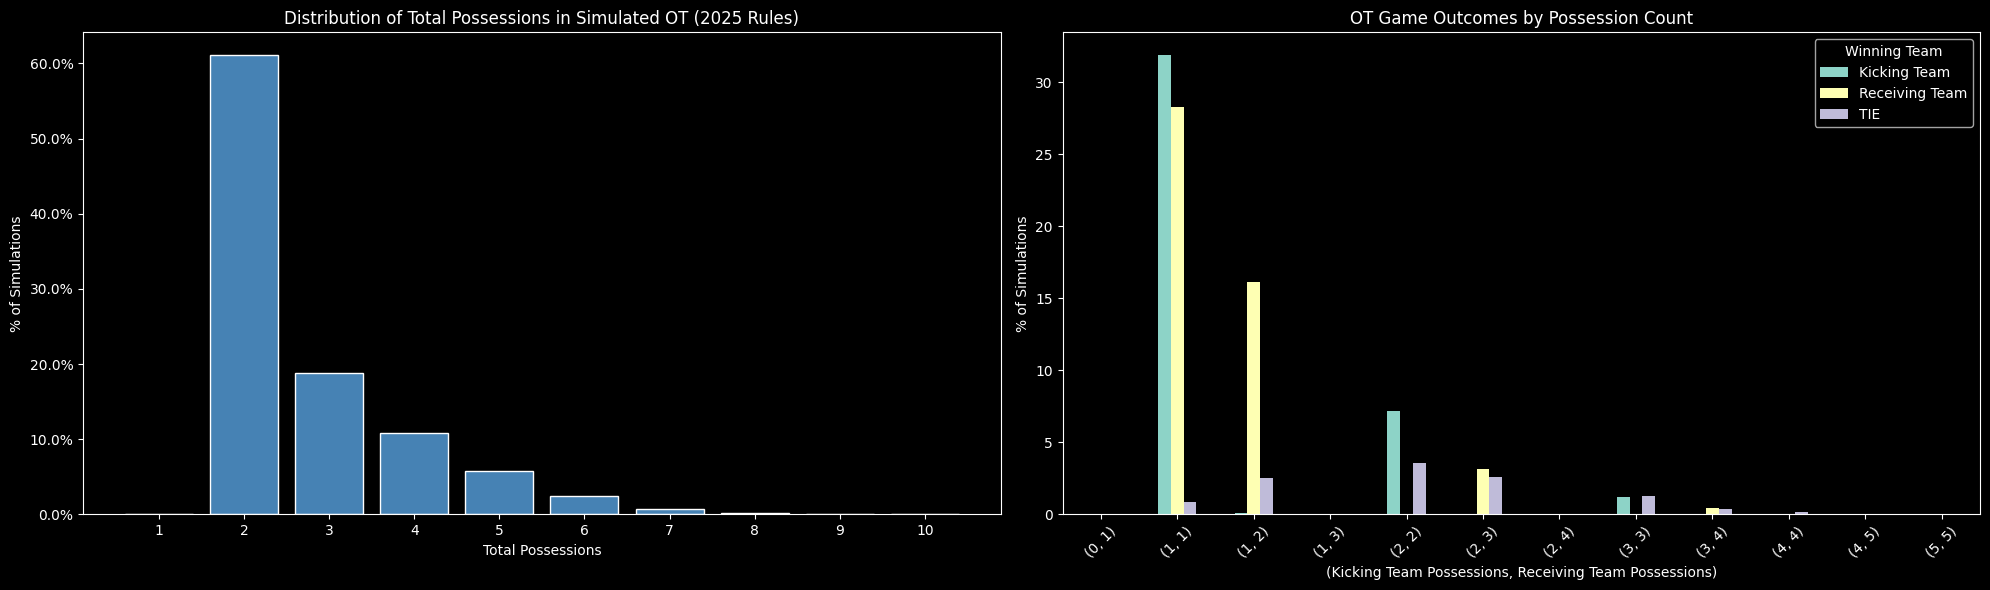

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# Top: outcomes by drive count
counts = (
    df2025.groupby(['Kicking Team Possessions', 'Receiving Team Possessions', 'Winning Team'])['Winning Team']
    .count()
    .unstack('Winning Team', fill_value=0)
)
pcts = counts / len(df2025) * 100
pcts.plot(kind='bar', ax=ax2)
ax2.set_xlabel('(Kicking Team Possessions, Receiving Team Possessions)')
ax2.set_ylabel('% of Simulations')
ax2.set_title('OT Game Outcomes by Possession Count')
ax2.legend(title='Winning Team')
ax2.tick_params(axis='x', rotation=45)

# Bottom: total possession distribution
df2025['total_possessions'] = df2025['Kicking Team Possessions'] + df2025['Receiving Team Possessions']
possession_counts = df2025['total_possessions'].value_counts(normalize=True).sort_index() * 100
ax1.bar(possession_counts.index, possession_counts.values, color='steelblue', edgecolor='white')
ax1.set_xlabel('Total Possessions')
ax1.set_ylabel('% of Simulations')
ax1.set_title('Distribution of Total Possessions in Simulated OT (2025 Rules)')
ax1.set_xticks(possession_counts.index)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))

plt.tight_layout()
plt.show()

In [9]:
results_by_yard = drive_list[drive_list['season']>=2016].groupby(['start_yardline'])['drive_result'].value_counts(normalize = True)

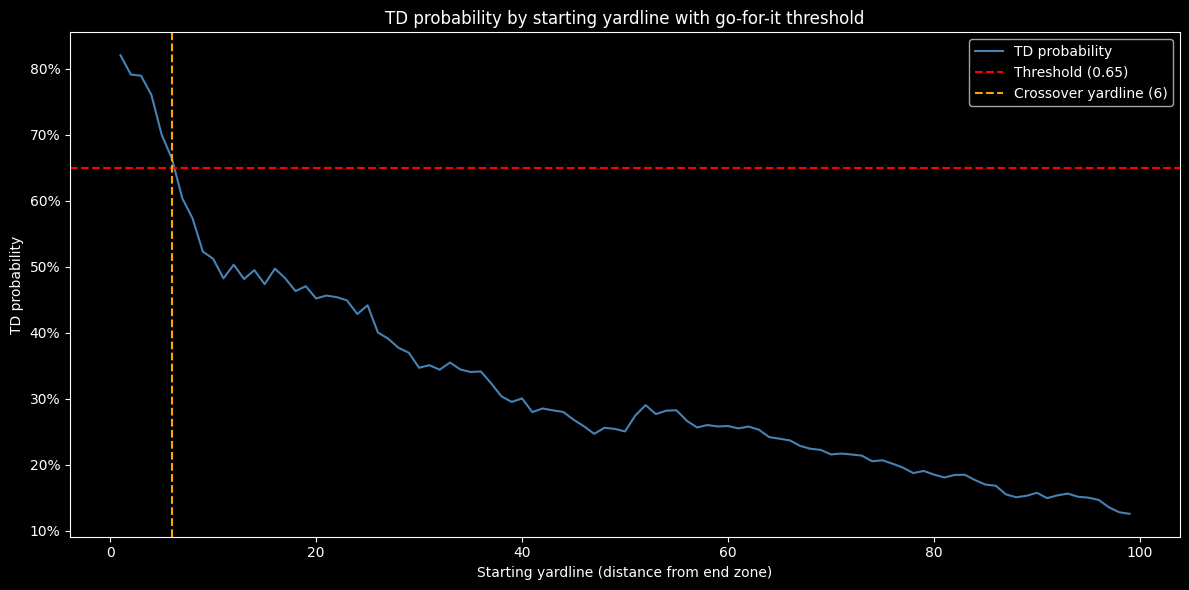

In [10]:

td_by_yard = (results_by_yard
    .unstack('drive_result', fill_value=0)
    .get('TOUCHDOWN', pd.Series(dtype=float))
    .reset_index()
    .rename(columns={'TOUCHDOWN': 'td_pct'}))

# Smooth with rolling average to reduce noise from low sample yardlines
td_by_yard = td_by_yard.sort_values('start_yardline')
td_by_yard['td_pct_smooth'] = td_by_yard['td_pct'].rolling(5, center=True, min_periods=1).mean()

# Find intersection at 0.44
threshold = 0.65
intersection = td_by_yard[td_by_yard['td_pct_smooth'] >= threshold]['start_yardline'].max()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(td_by_yard['start_yardline'], td_by_yard['td_pct_smooth'], color='steelblue', label='TD probability')
ax.axhline(threshold, color='red', linestyle='--', label=f'Threshold ({threshold})')
ax.axvline(intersection, color='orange', linestyle='--', label=f'Crossover yardline ({intersection})')
ax.set_xlabel('Starting yardline (distance from end zone)')
ax.set_ylabel('TD probability')
ax.set_title('TD probability by starting yardline with go-for-it threshold')
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

plt.tight_layout()
plt.savefig('td_threshold.png', dpi=150)
plt.show()

In [ ]:
df2025[(df2025['Kicking Team Possessions']+df2025['Kicking Team Possessions'] >= 4)]['Winning Team'].value_counts(normalize = True)

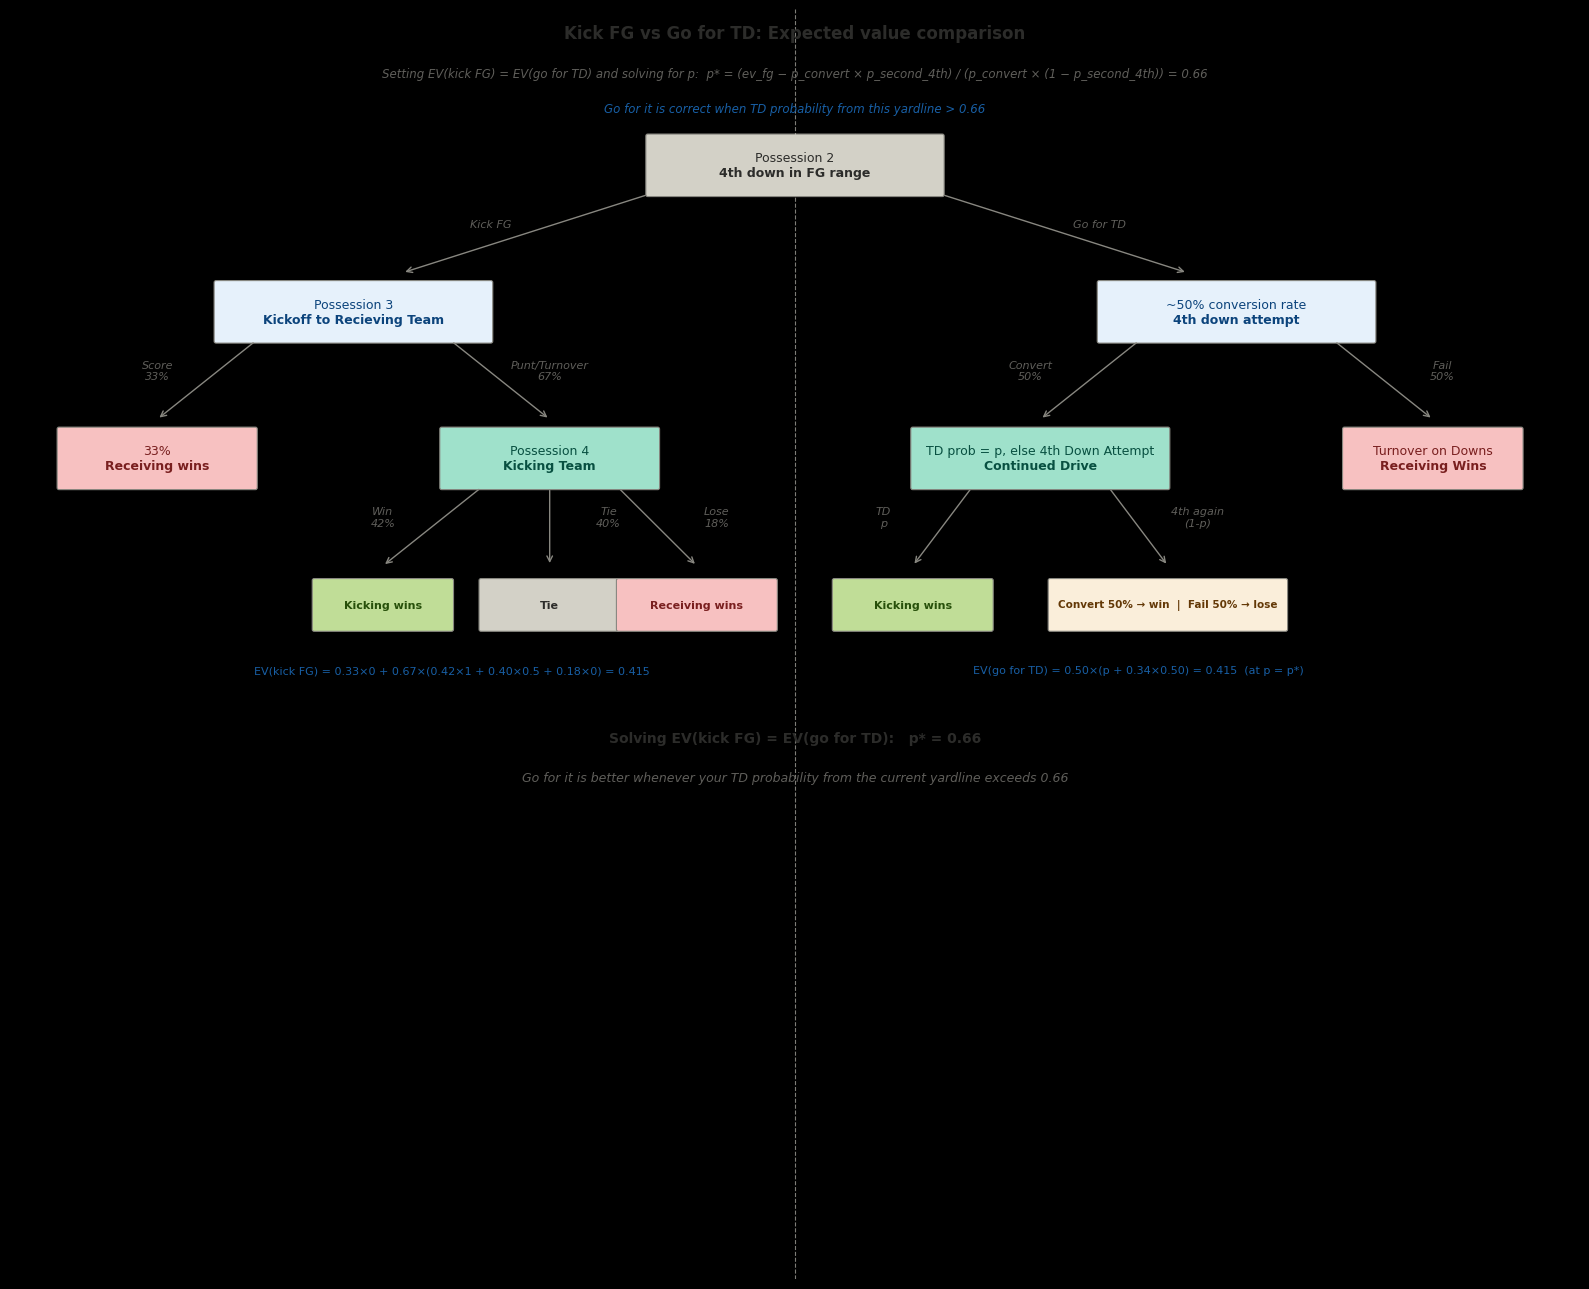

In [11]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

def draw_box(ax, x, y, w, h, text_lines, color='#E6F1FB', text_color='#0C447C', fontsize=9):
    box = FancyBboxPatch((x - w/2, y - h/2), w, h,
                         boxstyle="round,pad=0.02",
                         facecolor=color, edgecolor='#888780', linewidth=0.8)
    ax.add_patch(box)
    for i, line in enumerate(text_lines):
        offset = (i - (len(text_lines)-1)/2) * fontsize * 1.4
        weight = 'bold' if i == 0 else 'normal'
        ax.text(x, y + offset * 0.012, line, ha='center', va='center',
                fontsize=fontsize, fontweight=weight, color=text_color)

def draw_arrow(ax, x1, y1, x2, y2):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color='#888780', lw=1.0))

def draw_label(ax, x, y, text, fontsize=8):
    ax.text(x, y, text, ha='center', va='center', fontsize=fontsize,
            color='#5F5E5A', style='italic')

fig, ax = plt.subplots(figsize=(16, 13))
ax.set_xlim(0, 16)
ax.set_ylim(0, 13)
ax.axis('off')

# --- Assumptions (adjust these) ---
p_rec_score  = 0.33  # Probability receiving team scores on poss. 3
p_kick_win   = 0.42  # Probability kicking team wins on poss. 4
p_tie        = 0.40  # Probability of tie on poss. 4
p_kick_lose  = 0.18  # Probability kicking team loses on poss. 4
p_convert    = 0.50  # 4th down conversion rate
p_second_4th = 0.50  # Second 4th down conversion rate

# --- EV calculations ---
# EV(kick FG)
ev_fg = p_rec_score * 0 + (1 - p_rec_score) * (p_kick_win * 1 + p_tie * 0.5 + p_kick_lose * 0)

# EV(go for TD) = p_convert * (p * 1 + (1-p) * (p_second_4th * 1 + (1-p_second_4th) * 0))
#               = p_convert * (p + (1-p) * p_second_4th)
# Solve EV(go) = EV(fg) for p:
# p_convert * (p + (1-p) * p_second_4th) = ev_fg
# p_convert * p + p_convert * p_second_4th - p_convert * p_second_4th * p = ev_fg
# p * (p_convert - p_convert * p_second_4th) = ev_fg - p_convert * p_second_4th
# p = (ev_fg - p_convert * p_second_4th) / (p_convert * (1 - p_second_4th))
p_break = (ev_fg - p_convert * p_second_4th) / (p_convert * (1 - p_second_4th))
p = p_break  # use breakeven p to show the derivation

ev_go = p_convert * (p * 1 + (1 - p) * (p_second_4th * 1 + (1 - p_second_4th) * 0))

# --- Title ---
ax.text(8, 12.7, 'Kick FG vs Go for TD: Expected value comparison',
        ha='center', fontsize=12, fontweight='bold', color='#2C2C2A')
ax.text(8, 12.3, f'Setting EV(kick FG) = EV(go for TD) and solving for p:  '
                 f'p* = (ev_fg − p_convert × p_second_4th) / (p_convert × (1 − p_second_4th)) = {p_break:.2f}',
        ha='center', fontsize=8.5, color='#5F5E5A', style='italic')
ax.text(8, 11.95, f'Go for it is correct when TD probability from this yardline > {p_break:.2f}',
        ha='center', fontsize=8.5, color='#185FA5', style='italic')

# --- Root node ---
draw_box(ax, 8, 11.4, 3, 0.6, ['4th down in FG range', 'Possession 2'],
         color='#D3D1C7', text_color='#2C2C2A')

# --- Left branch: Kick FG ---
draw_arrow(ax, 6.5, 11.1, 4.0, 10.3)
draw_label(ax, 4.9, 10.8, 'Kick FG')
draw_box(ax, 3.5, 9.9, 2.8, 0.6, ['Kickoff to Recieving Team', 'Possession 3'],
         color='#E6F1FB', text_color='#0C447C')

# Poss 3 branches
draw_arrow(ax, 2.5, 9.6, 1.5, 8.8)
draw_label(ax, 1.5, 9.3, f'Score\n{p_rec_score:.0%}')
draw_arrow(ax, 4.5, 9.6, 5.5, 8.8)
draw_label(ax, 5.5, 9.3, f'Punt/Turnover\n{1-p_rec_score:.0%}')

draw_box(ax, 1.5, 8.4, 2.0, 0.6, ['Receiving wins', f'{p_rec_score:.0%}'],
         color='#F7C1C1', text_color='#791F1F')
draw_box(ax, 5.5, 8.4, 2.2, 0.6, ['Kicking Team', 'Possession 4'],
         color='#9FE1CB', text_color='#085041')

# Three branches from kicking poss. 4
draw_arrow(ax, 4.8, 8.1, 3.8, 7.3)
draw_label(ax, 3.8, 7.8, f'Win\n{p_kick_win:.0%}')
draw_arrow(ax, 5.5, 8.1, 5.5, 7.3)
draw_label(ax, 6.1, 7.8, f'Tie\n{p_tie:.0%}')
draw_arrow(ax, 6.2, 8.1, 7.0, 7.3)
draw_label(ax, 7.2, 7.8, f'Lose\n{p_kick_lose:.0%}')

draw_box(ax, 3.8, 6.9, 1.4, 0.5, ['Kicking wins'],
         color='#C0DD97', text_color='#27500A', fontsize=8)
draw_box(ax, 5.5, 6.9, 1.4, 0.5, ['Tie'],
         color='#D3D1C7', text_color='#2C2C2A', fontsize=8)
draw_box(ax, 7.0, 6.9, 1.6, 0.5, ['Receiving wins'],
         color='#F7C1C1', text_color='#791F1F', fontsize=8)

# EV left
ax.text(4.5, 6.2,
        f'EV(kick FG) = {p_rec_score:.2f}×0 + {1-p_rec_score:.2f}×({p_kick_win:.2f}×1 + {p_tie:.2f}×0.5 + {p_kick_lose:.2f}×0) = {ev_fg:.3f}',
        ha='center', fontsize=8, color='#185FA5')

# --- Right branch: Go for TD ---
draw_arrow(ax, 9.5, 11.1, 12.0, 10.3)
draw_label(ax, 11.1, 10.8, 'Go for TD')
draw_box(ax, 12.5, 9.9, 2.8, 0.6,
         ['4th down attempt', f'~{p_convert:.0%} conversion rate'],
         color='#E6F1FB', text_color='#0C447C')

# Convert / Fail
draw_arrow(ax, 11.5, 9.6, 10.5, 8.8)
draw_label(ax, 10.4, 9.3, f'Convert\n{p_convert:.0%}')
draw_arrow(ax, 13.5, 9.6, 14.5, 8.8)
draw_label(ax, 14.6, 9.3, f'Fail\n{1-p_convert:.0%}')

draw_box(ax, 10.5, 8.4, 2.6, 0.6,
         ['Continued Drive', f'TD prob = p, else 4th Down Attempt'],
         color='#9FE1CB', text_color='#085041')
draw_box(ax, 14.5, 8.4, 1.8, 0.6, ['Receiving Wins', 'Turnover on Downs'],
         color='#F7C1C1', text_color='#791F1F')

# TD / second 4th
draw_arrow(ax, 9.8, 8.1, 9.2, 7.3)
draw_label(ax, 8.9, 7.8, f'TD\np')
draw_arrow(ax, 11.2, 8.1, 11.8, 7.3)
draw_label(ax, 12.1, 7.8, f'4th again\n(1-p)')

draw_box(ax, 9.2, 6.9, 1.6, 0.5, ['Kicking wins'],
         color='#C0DD97', text_color='#27500A', fontsize=8)
draw_box(ax, 11.8, 6.9, 2.4, 0.5,
         [f'Convert {p_second_4th:.0%} → win  |  Fail {1-p_second_4th:.0%} → lose'],
         color='#FAEEDA', text_color='#633806', fontsize=7.5)

# EV right
ax.text(11.5, 6.2,
        f'EV(go for TD) = {p_convert:.2f}×(p + {1-p_break:.2f}×{p_second_4th:.2f}) = {ev_go:.3f}  (at p = p*)',
        ha='center', fontsize=8, color='#185FA5')

# --- Breakeven annotation ---
ax.text(8, 5.5,
        f'Solving EV(kick FG) = EV(go for TD):   p* = {p_break:.2f}',
        ha='center', fontsize=10, fontweight='bold', color='#2C2C2A')
ax.text(8, 5.1,
        f'Go for it is better whenever your TD probability from the current yardline exceeds {p_break:.2f}',
        ha='center', fontsize=9, color='#5F5E5A', style='italic')

# --- VS divider ---
ax.axvline(8, color='#D3D1C7', linestyle='--', linewidth=0.8, alpha=0.6)

plt.tight_layout()
plt.savefig('decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
DATA_DIR = r"C://Users//natel//PycharmProjects//NFL_Overtime_Model//data"
df = pd.read_parquet(f'{DATA_DIR}//pbp_data.parquet')
drive_list = pd.read_csv(f'{DATA_DIR}//drive_list.csv')
drive_list['season'] = drive_list['drive_id'].str[:4].astype(int)
ko_list = pd.read_csv(f"{DATA_DIR}//ko_list.csv")


In [13]:
drive_list[drive_list['season'] == 2025]['drive_id'].sample(1)

154196    2025_20_HOU_NE_23
Name: drive_id, dtype: object

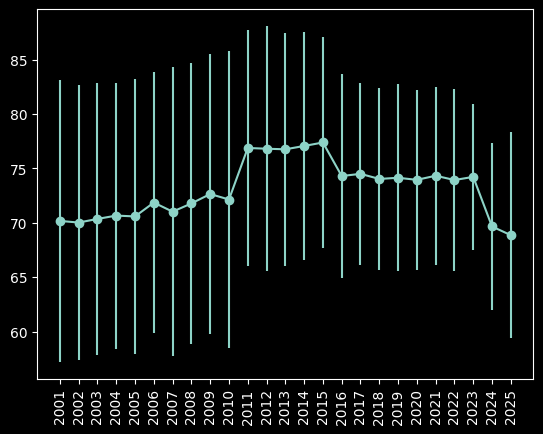

In [14]:
agg = ko_list.groupby('season')['starting_field_position'].agg(['mean', 'std'])
plt.errorbar(agg.index, agg['mean'], yerr=agg['std'], fmt='o-')
plt.xticks(agg.index.astype(int),rotation=90)

plt.show()

In [16]:
drive_list['season'] = drive_list['drive_id'].str[:4].astype(int)
print(drive_list.groupby('season')['drive_result']
      .apply(lambda x: (x == 'TOUCHDOWN').mean())
      .round(3))

season
2001    0.170
2002    0.193
2003    0.180
2004    0.193
2005    0.179
2006    0.180
2007    0.189
2008    0.193
2009    0.193
2010    0.194
2011    0.191
2012    0.196
2013    0.199
2014    0.203
2015    0.201
2016    0.212
2017    0.193
2018    0.225
2019    0.219
2020    0.252
2021    0.230
2022    0.212
2023    0.206
2024    0.229
2025    0.230
Name: drive_result, dtype: float64


In [17]:
tied_drives = drive_list[drive_list['start_score_diff'] == 0]
print(tied_drives['drive_result'].value_counts(normalize=True))

drive_result
PUNT                    0.450355
TOUCHDOWN               0.200811
FIELD_GOAL              0.160765
INTERCEPTION            0.066422
FUMBLE                  0.045128
MISSED_FG               0.031288
DOWNS                   0.020229
END_HALF                0.018340
SAFETY                  0.002129
BLOCKED_FG              0.001889
BLOCKED_PUNT            0.001545
FUMBLE,_SAFETY          0.000309
END_GAME                0.000275
BLOCKED_PUNT,_DOWNS     0.000206
BLOCKED_FG,_DOWNS       0.000137
BLOCKED_FG_DOWNS        0.000069
BLOCKED_PUNT_DOWNS      0.000034
FUMBLE_SAFETY           0.000034
BLOCKED_PUNT,_SAFETY    0.000034
Name: proportion, dtype: float64


In [18]:
ko_list['rule_set'] = ko_list['season'].apply(lambda x: get_ruleset(x, 1))
ko_list.groupby('rule_set')['starting_field_position'].mean()

NameError: name 'get_ruleset' is not defined

In [19]:
import pandas as pd

def get_ruleset(season, week):
    is_playoff = week > 18
    if season >= 2025:
        return '2025'
    elif season == 2024:
        return '2024'  # dynamic kickoff, old OT rules
    elif season >= 2022 and is_playoff:
        return '2025'  # playoff OT same as 2025 rules
    elif season >= 2017:
        return '2017_2023'  # 35-yard kickoff
    elif season == 2016:
        return '2016'  # 25-yard touchback
    elif season >= 2012:
        return '2012_2015'  # FG-match era, 15-min OT
    else:
        return 'pre2012'  # pure sudden death

def aggregate_overtime_games(pbp: pd.DataFrame) -> pd.DataFrame:
    ot_plays = pbp[pbp['game_half'] == 'Overtime'].copy()

    results = []

    for game_id, game in ot_plays.groupby('game_id'):
        game = game.sort_values('play_id')

        first_play = game.iloc[0]
        season = first_play['season']
        week = first_play['week']
        receiving_team = first_play['posteam']

        home = first_play['home_team']
        away = first_play['away_team']
        kicking_team = away if receiving_team == home else home

        last_play = game.iloc[-1]
        home_score = last_play['total_home_score']
        away_score = last_play['total_away_score']

        if home_score > away_score:
            winner = home
        elif away_score > home_score:
            winner = away
        else:
            winner = 'TIE'

        results.append({
            'game_id': game_id,
            'season': season,
            'week': week,
            'ruleset': get_ruleset(season, week),
            'kicking_team': kicking_team,
            'receiving_team': receiving_team,
            'winner': winner,
            'kicking_team_won': winner == kicking_team,
            'receiving_team_won': winner == receiving_team,
            'tie': winner == 'TIE',
        })

    return pd.DataFrame(results).sort_values(['season', 'week']).reset_index(drop=True)

In [20]:
drive_list['season'] = drive_list['drive_id'].str[:4].astype(int)


In [21]:
pcts = (
  drive_list.groupby(['season','start_yardline'])['drive_result']
  .value_counts(normalize=True)
  .unstack(fill_value=0)
)

pcts['SCORING'] = pcts['TOUCHDOWN']+pcts['FIELD_GOAL']
pcts.to_csv('scoring_pct.csv')

In [ ]:
%%sql


In [22]:
drives2025 = drive_list[(drive_list['season'] == 2025) & (~drive_list['drive_result'].isin(['END_GAME', 'END_HALF']))]
turnovers = drives2025['drive_result'].isin(['INTERCEPTION','FUMBLE', 'MISSED_FG', 'BLOCKED_FG', 'DOWNS', 'BLOCKED_PUNT']).sum()/len(drives2025)
time =drives2025['time_elapsed'].mean()
results = drives2025['drive_result'].value_counts(normalize=True)
print(f'Each drive takes on average {time:.0f} seconds')
print(f'Touchdown %: {results['TOUCHDOWN']*100:.2f}%')
print(f'Field Goal %: {results['FIELD_GOAL']*100:.2f}%')
print(f'Punt %: {results['PUNT']*100:.2f}%')
print(f'Turnover %: {turnovers*100:.2f}%')


Each drive takes on average 178 seconds
Touchdown %: 24.69%
Field Goal %: 17.45%
Punt %: 36.33%
Turnover %: 21.21%


In [23]:
drive_list.groupby('start_yardline')['drive_result'].value_counts(normalize = True)

start_yardline  drive_result  
1               TOUCHDOWN         0.839623
                FIELD_GOAL        0.084906
                END_GAME          0.028302
                DOWNS             0.018868
                FUMBLE            0.009434
                                    ...   
99              DOWNS             0.019495
                MISSED_FG         0.013761
                FUMBLE,_SAFETY    0.004587
                BLOCKED_PUNT      0.002294
                BLOCKED_FG        0.001147
Name: proportion, Length: 1079, dtype: float64

In [24]:
ot_df = aggregate_overtime_games(df)#[df['season']>=2006])

In [25]:
df['season'].min()

np.int64(2001)

In [26]:
ot_df.groupby(['ruleset']).agg(
    games=('game_id', 'count'),
    receiving_won=('receiving_team_won', 'sum'),
    kicking_won=('kicking_team_won', 'sum'),
    ties=('tie', 'sum'),
    receiving_pct=('receiving_team_won', 'mean'),
    kicking_pct=('kicking_team_won', 'mean'),
    tie_pct=('tie', 'mean'),
).round(3)


,games,receiving_won,kicking_won,ties,receiving_pct,kicking_pct,tie_pct
ruleset,,,,,,,
2012_2015,73,37,32,4,0.507,0.438,0.055
2016,14,6,6,2,0.429,0.429,0.143
2017_2023,108,58,42,8,0.537,0.389,0.074
2024,16,12,3,1,0.750,0.188,0.062
2025,17,9,7,1,0.529,0.412,0.059
pre2012,191,106,83,2,0.555,0.435,0.010
